<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/Exercise-Pose-Correction-_Module-AAI/blob/main/AAI_Exercise_Pose_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q mediapipe==0.10.13
!pip install -q opencv-python-headless kaggle
print(" Installation OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
 Installation OK


In [2]:

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
warnings.filterwarnings('ignore')


In [3]:

# Dossiers de travail
BASE = '/content/fitness_data'
for folder in ['videos/raw', 'processed', 'results']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

In [4]:

# Les 7 angles qu'on va calculer (= nos features)
ANGLE_NAMES = [
    'genou_gauche',   # Hanche G → Genou G → Cheville G
    'genou_droit',    # Hanche D → Genou D → Cheville D
    'hanche_gauche',  # Épaule G → Hanche G → Genou G
    'hanche_droite',  # Épaule D → Hanche D → Genou D
    'coude_gauche',   # Épaule G → Coude G → Poignet G
    'coude_droit',    # Épaule D → Coude D → Poignet D
    'tronc',          # Nez → Épaule G → Hanche G
]

In [5]:
# Téléchargement du modèle MediaPipe
print("📥 Téléchargement du modèle MediaPipe...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    "pose_landmarker.task"
)


# Création du détecteur
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options      = vision.PoseLandmarkerOptions(base_options=base_options)
detector     = vision.PoseLandmarker.create_from_options(options)

print("✅ Imports OK")
print("✅ MediaPipe détecteur OK")
print(f"📁 Dossiers créés dans {BASE}")


📥 Téléchargement du modèle MediaPipe...
✅ Imports OK
✅ MediaPipe détecteur OK
📁 Dossiers créés dans /content/fitness_data


In [6]:
# Configuration Kaggle
import os, json

KAGGLE_USERNAME = "khadijaaitoufkir"
KAGGLE_KEY      = "KGAT_1b1de71842f7a9624e3d649e105da702"

# Création du kaggle.json manuellement
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_config, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ kaggle.json créé")

# Téléchargement du dataset
BASE = '/content/fitness_data'
print("\n📥 Téléchargement des vidéos...")
!kaggle datasets download -d hasyimabdillah/workoutfitness-video \
    -p {BASE}/videos/raw --unzip --quiet

print("\n📁 Vidéos disponibles :")
!find {BASE}/videos/raw -name "*.mp4" | wc -l
print("vidéos téléchargées")

✅ kaggle.json créé

📥 Téléchargement des vidéos...
Dataset URL: https://www.kaggle.com/datasets/hasyimabdillah/workoutfitness-video
License(s): CC-BY-NC-SA-4.0

📁 Vidéos disponibles :
590
vidéos téléchargées


In [7]:
import glob

all_videos = glob.glob(f'{BASE}/videos/raw/**/*.mp4', recursive=True)
print(f"Total vidéos : {len(all_videos)}\n")

for v in sorted(all_videos)[:15]:
    print(f"  {v.replace(f'{BASE}/videos/raw/', '')}")
if len(all_videos) > 15:
    print(f"  ... et {len(all_videos)-15} autres")

# Filtrage : on garde squat, pushup, lunge
video_map = {}
for v in all_videos:
    name   = os.path.basename(v).lower()
    folder = os.path.dirname(v).lower()
    for ex in ['squat', 'push_up', 'pushup', 'lunge']:
        if ex in name or ex in folder:
            clean = 'pushup' if 'push' in ex else ex
            video_map.setdefault(clean, []).append(v)
            break

print(f"\nVidéos par exercice :")
for ex, vids in video_map.items():
    print(f"  {ex:15s} : {len(vids)} vidéos")



Total vidéos : 590

  barbell biceps curl/barbell biceps curl_1.mp4
  barbell biceps curl/barbell biceps curl_10.mp4
  barbell biceps curl/barbell biceps curl_11.mp4
  barbell biceps curl/barbell biceps curl_12.mp4
  barbell biceps curl/barbell biceps curl_13.mp4
  barbell biceps curl/barbell biceps curl_14.mp4
  barbell biceps curl/barbell biceps curl_15.mp4
  barbell biceps curl/barbell biceps curl_16.mp4
  barbell biceps curl/barbell biceps curl_17.mp4
  barbell biceps curl/barbell biceps curl_18.mp4
  barbell biceps curl/barbell biceps curl_19.mp4
  barbell biceps curl/barbell biceps curl_2.mp4
  barbell biceps curl/barbell biceps curl_20.mp4
  barbell biceps curl/barbell biceps curl_21.mp4
  barbell biceps curl/barbell biceps curl_22.mp4
  ... et 575 autres

Vidéos par exercice :
  squat           : 23 vidéos


In [8]:

# Index des 33 landmarks MediaPipe
LM = {
    'nez':        0,
    'epaule_g':   11, 'epaule_d':   12,
    'coude_g':    13, 'coude_d':    14,
    'poignet_g':  15, 'poignet_d':  16,
    'hanche_g':   23, 'hanche_d':   24,
    'genou_g':    25, 'genou_d':    26,
    'cheville_g': 27, 'cheville_d': 28,
}

# 7 triplets (A, B, C) — B est le sommet de l'angle
ANGLE_TRIPLETS = [
    (LM['hanche_g'],  LM['genou_g'],  LM['cheville_g']),  # genou gauche
    (LM['hanche_d'],  LM['genou_d'],  LM['cheville_d']),  # genou droit
    (LM['epaule_g'],  LM['hanche_g'], LM['genou_g']),     # hanche gauche
    (LM['epaule_d'],  LM['hanche_d'], LM['genou_d']),     # hanche droite
    (LM['epaule_g'],  LM['coude_g'],  LM['poignet_g']),   # coude gauche
    (LM['epaule_d'],  LM['coude_d'],  LM['poignet_d']),   # coude droit
    (LM['nez'],       LM['epaule_g'], LM['hanche_g']),    # tronc
]

def calculate_angle(A, B, C):
    """Angle en degrés au sommet B entre BA et BC."""
    BA = A - B
    BC = C - B
    cos_a = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def extract_angles_from_landmarks(landmarks):
    """
    landmarks : liste de NormalizedLandmark (nouvelle API MediaPipe)
    Retourne : array (7,) des angles en degrés
    """
    pts = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    return np.array([calculate_angle(pts[a], pts[b], pts[c])
                     for (a, b, c) in ANGLE_TRIPLETS])

# Test
A = np.array([0, 1, 0])
B = np.array([0, 0, 0])
C = np.array([1, 0, 0])
print(f"Test angle à 90° → {calculate_angle(A, B, C):.1f}°  ✅")


Test angle à 90° → 90.0°  ✅


In [9]:

SEQ_LEN = 60  # frames par séquence

def extract_sequences_from_video(video_path, seq_len=SEQ_LEN):
    """
    Extrait des séquences d'angles depuis une vidéo MP4.
    Retourne : liste de np.array (seq_len, 7)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    sequences   = []
    current_seq = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Conversion BGR → RGB pour MediaPipe
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)

        # Si des landmarks sont détectés
        if result.pose_landmarks and len(result.pose_landmarks) > 0:
            landmarks = result.pose_landmarks[0]  # première personne
            angles    = extract_angles_from_landmarks(landmarks)
            current_seq.append(angles)

            if len(current_seq) == seq_len:
                sequences.append(np.array(current_seq))
                current_seq = current_seq[30:]  # 50% overlap

    cap.release()
    return sequences


# Extraction de toutes les vidéos
print("🔄 Extraction des keypoints (5-10 minutes)...\n")

sequences_correct = []
labels_correct    = []
meta_correct      = []

for exercise, video_list in video_map.items():
    ex_seqs = 0
    for vpath in video_list:
        seqs = extract_sequences_from_video(vpath)
        for seq in seqs:
            sequences_correct.append(seq)
            labels_correct.append(0)  # 0 = CORRECT (coachs experts)
            meta_correct.append({
                'exercise':  exercise,
                'label':     0,
                'label_str': 'correct',
                'source':    'kaggle'
            })
            ex_seqs += 1
    print(f"  ✅ {exercise:15s} : {ex_seqs} séquences extraites")

print(f"\n  Total séquences correctes : {len(sequences_correct)}")



🔄 Extraction des keypoints (5-10 minutes)...

  ✅ squat           : 127 séquences extraites

  Total séquences correctes : 127


In [10]:

ERRORS = {
    'squat': {
        'genou_valgus':  {'indices': [0, 1], 'perturbation': -25, 'zone': 'bas'},
        'tronc_penche':  {'indices': [6],    'perturbation': -20, 'zone': 'partout'},
    },
    'pushup': {
        'hanches_affaissees': {'indices': [2, 3], 'perturbation': -25, 'zone': 'partout'},
        'tronc_casse':        {'indices': [6],     'perturbation': -20, 'zone': 'partout'},
    },
    'lunge': {
        'genou_en_avant': {'indices': [0], 'perturbation': -20, 'zone': 'bas'},
        'tronc_penche':   {'indices': [6], 'perturbation': -18, 'zone': 'partout'},
    },
}

def generate_incorrect(seq_correct, exercise, error_name):
    """
    Injecte une erreur biomécanique dans une séquence correcte.
    """
    seq = seq_correct.copy()
    error = ERRORS.get(exercise, {}).get(error_name)
    if not error:
        return seq

    for i in range(len(seq)):
        # Intensité : max au point bas (frame 30), nulle en position debout
        intensity = np.sin(np.pi * i / len(seq)) if error['zone'] == 'bas' else 1.0
        noise     = np.random.normal(0, 3)
        for idx in error['indices']:
            seq[i, idx] += error['perturbation'] * intensity + noise
            seq[i, idx]  = np.clip(seq[i, idx], 5, 175)
    return seq


print("🔄 Génération des séquences incorrectes...")
np.random.seed(42)

sequences_incorrect = []
labels_incorrect    = []
meta_incorrect      = []

for seq, meta_item in zip(sequences_correct, meta_correct):
    exercise = meta_item['exercise']
    for error_name in ERRORS.get(exercise, {}).keys():
        seq_bad = generate_incorrect(seq, exercise, error_name)
        sequences_incorrect.append(seq_bad)
        labels_incorrect.append(1)
        meta_incorrect.append({
            'exercise':  exercise,
            'label':     1,
            'label_str': 'incorrect',
            'source':    'generated',
            'erreur':    error_name,
        })

print(f"  ✅ Séquences incorrectes : {len(sequences_incorrect)}")


🔄 Génération des séquences incorrectes...
  ✅ Séquences incorrectes : 254


In [11]:
X    = np.array(sequences_correct + sequences_incorrect)
y    = np.array(labels_correct    + labels_incorrect)
meta = pd.DataFrame(meta_correct  + meta_incorrect)

print(f"Dataset brut : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")

# Équilibrage si déséquilibre > 20%
n_min = min(np.sum(y==0), np.sum(y==1))
if abs(np.sum(y==0) - np.sum(y==1)) / len(y) > 0.2:
    idx_0 = np.where(y==0)[0][:n_min]
    idx_1 = np.where(y==1)[0][:n_min]
    idx   = np.concatenate([idx_0, idx_1])
    np.random.shuffle(idx)
    X, y, meta = X[idx], y[idx], meta.iloc[idx].reset_index(drop=True)
    print(f"⚖️  Équilibré à {n_min} par classe")

print(f"Dataset final : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")



Dataset brut : (381, 60, 7)  |  Correct=127  Incorrect=254
⚖️  Équilibré à 127 par classe
Dataset final : (254, 60, 7)  |  Correct=127  Incorrect=127


In [12]:
from sklearn.preprocessing import StandardScaler

N, T, F = X.shape
scaler  = StandardScaler()
X_norm  = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f"Normalisation :")
print(f"  Avant : min={X.min():.1f}°  max={X.max():.1f}°  mean={X.mean():.1f}°")
print(f"  Après : min={X_norm.min():.2f}  max={X_norm.max():.2f}  mean={X_norm.mean():.3f}")


Normalisation :
  Avant : min=5.0°  max=179.7°  mean=111.4°
  Après : min=-4.34  max=2.83  mean=0.000


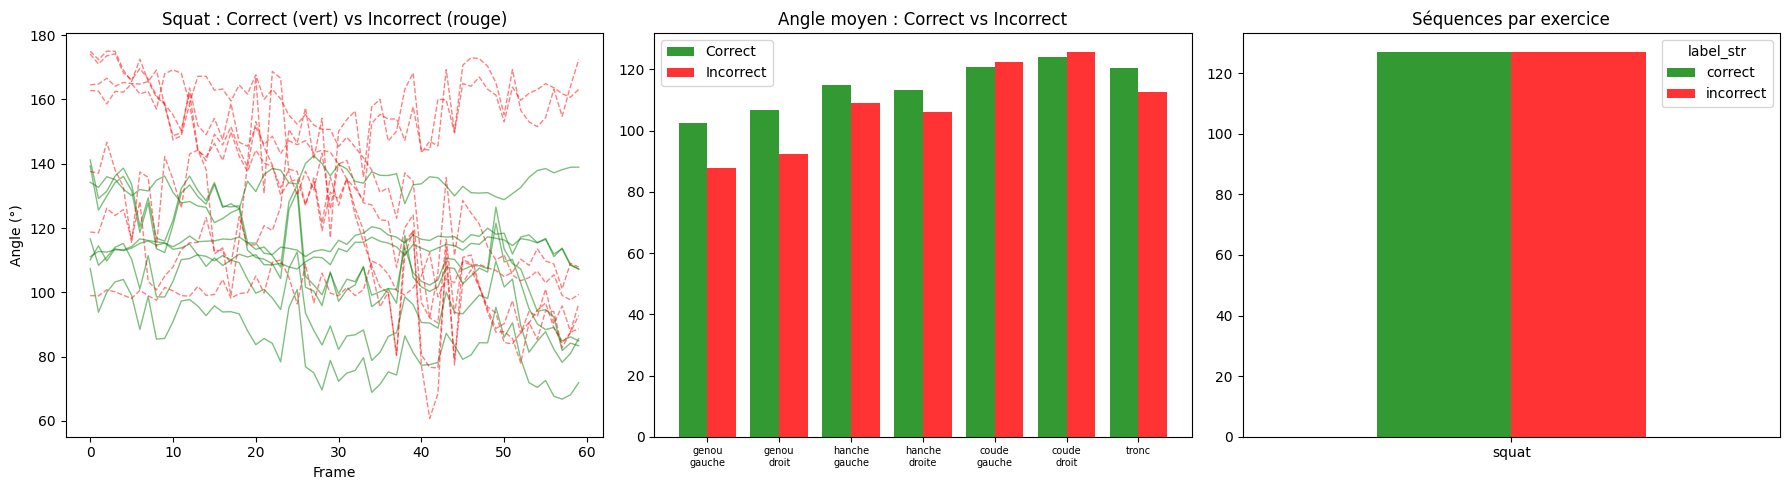

✅ EDA sauvegardée


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : séquence correcte vs incorrecte
idx_c = meta[(meta.exercise=='squat') & (meta.label==0)].index[0]
idx_i = meta[(meta.exercise=='squat') & (meta.label==1)].index[0]
for j in range(7):
    axes[0].plot(X[idx_c, :, j], color='green', alpha=0.5, lw=1)
    axes[0].plot(X[idx_i, :, j], color='red',   alpha=0.5, lw=1, linestyle='--')
axes[0].set_title('Squat : Correct (vert) vs Incorrect (rouge)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Angle (°)')

# Graphique 2 : angle moyen par classe
X_mean  = X.mean(axis=1)
m_corr  = X_mean[y==0].mean(axis=0)
m_incr  = X_mean[y==1].mean(axis=0)
x_pos   = np.arange(7)
axes[1].bar(x_pos - 0.2, m_corr, 0.4, color='green', alpha=0.8, label='Correct')
axes[1].bar(x_pos + 0.2, m_incr, 0.4, color='red',   alpha=0.8, label='Incorrect')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('_','\n') for n in ANGLE_NAMES], fontsize=7)
axes[1].set_title('Angle moyen : Correct vs Incorrect')
axes[1].legend()

# Graphique 3 : distribution par exercice
meta.groupby(['exercise','label_str']).size().unstack().plot(
    kind='bar', ax=axes[2], color=['green','red'], alpha=0.8
)
axes[2].set_title('Séquences par exercice')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/results/eda_jour1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA sauvegardée")


In [14]:
np.save(f'{BASE}/processed/X.npy',    X_norm)
np.save(f'{BASE}/processed/y.npy',    y)
meta.to_csv(f'{BASE}/processed/meta.csv', index=False)
with open(f'{BASE}/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Fichiers sauvegardés dans /content/fitness_data/processed/")
print(f"   X.npy      : {X_norm.shape}")
print(f"   y.npy      : {y.shape}")
print(f"   meta.csv   : {len(meta)} lignes")
print(f"   scaler.pkl : StandardScaler (7 features)")


✅ Fichiers sauvegardés dans /content/fitness_data/processed/
   X.npy      : (254, 60, 7)
   y.npy      : (254,)
   meta.csv   : 254 lignes
   scaler.pkl : StandardScaler (7 features)


#Jour 2 — Entraînement du BiLSTM


In [15]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Imports OK')
print(f'Device : {DEVICE}')


Imports OK
Device : cpu


In [16]:

N, T, F = X.shape  # nb_sequences, 60 frames, 7 angles

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.167, random_state=42, stratify=y_temp
)

print(f'Split effectue :')
print(f'  Train : {len(X_train):4d} sequences ({len(X_train)/N*100:.0f}%)')
print(f'  Val   : {len(X_val):4d} sequences ({len(X_val)/N*100:.0f}%)')
print(f'  Test  : {len(X_test):4d} sequences ({len(X_test)/N*100:.0f}%)')


Split effectue :
  Train :  189 sequences (74%)
  Val   :   39 sequences (15%)
  Test  :   26 sequences (10%)


In [17]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.167, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} sequences")
print(f"Val   : {X_val.shape[0]} sequences")
print(f"Test  : {X_test.shape[0]} sequences")

Train : 189 sequences
Val   : 39 sequences
Test  : 26 sequences


In [18]:

class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 16

train_loader = DataLoader(PoseDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PoseDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(PoseDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches train : {len(train_loader)}')
print(f'Batches val   : {len(val_loader)}')

Batches train : 12
Batches val   : 3


In [19]:
class PoseBiLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=128,
                 num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0
        )

        self.norm    = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)      # (batch, 60, 256)
        out    = out[:, -1, :]     # derniere frame uniquement (batch, 256)
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)        # (batch, 2)


model = PoseBiLSTM().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parametres total : {total_params:,}')
print(model)

Parametres total : 552,642
PoseBiLSTM(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

In [21]:

EPOCHS       = 60
best_val_acc = 0.0
history      = {'train_loss': [], 'val_loss': [],
                'train_acc':  [], 'val_acc':  []}

BASE = '/content/fitness_data'
import os
os.makedirs(f'{BASE}/results', exist_ok=True)

for epoch in range(EPOCHS):

    # -- TRAIN --
    model.train()
    train_loss, train_correct = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == yb).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(X_train)

    # -- VAL --
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out        = model(xb)
            val_loss  += criterion(out, yb).item()
            val_correct += (out.argmax(1) == yb).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(X_val)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{BASE}/processed/model.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | '
              f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

print(f'\nMeilleur val_acc : {best_val_acc:.4f}')
print(f'model.pt sauvegarde')


Epoch  10/60 | train_loss=0.6436  train_acc=0.635 | val_loss=0.6820  val_acc=0.590
Epoch  20/60 | train_loss=0.5610  train_acc=0.720 | val_loss=0.6040  val_acc=0.641
Epoch  30/60 | train_loss=0.4964  train_acc=0.778 | val_loss=0.6271  val_acc=0.615
Epoch  40/60 | train_loss=0.3040  train_acc=0.857 | val_loss=0.7832  val_acc=0.667
Epoch  50/60 | train_loss=0.1826  train_acc=0.915 | val_loss=0.6225  val_acc=0.769
Epoch  60/60 | train_loss=0.1470  train_acc=0.958 | val_loss=0.6071  val_acc=0.769

Meilleur val_acc : 0.7692
model.pt sauvegarde


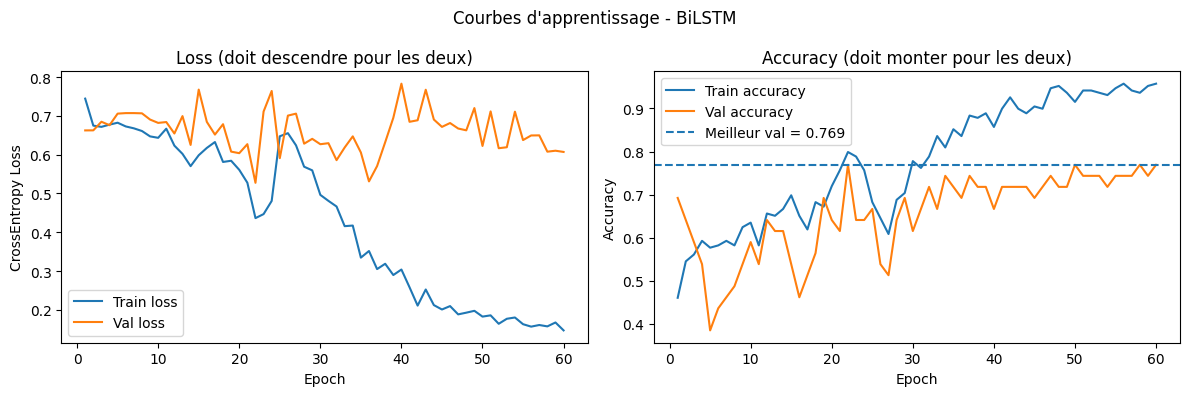

training_curves.png sauvegarde


In [22]:

ep = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, history['train_loss'], label='Train loss')
ax1.plot(ep, history['val_loss'],   label='Val loss')
ax1.set_title('Loss (doit descendre pour les deux)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.legend()

ax2.plot(ep, history['train_acc'], label='Train accuracy')
ax2.plot(ep, history['val_acc'],   label='Val accuracy')
ax2.axhline(y=best_val_acc, linestyle='--',
            label=f'Meilleur val = {best_val_acc:.3f}')
ax2.set_title('Accuracy (doit monter pour les deux)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Courbes d\'apprentissage - BiLSTM')
plt.tight_layout()
plt.savefig(f'{BASE}/results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('training_curves.png sauvegarde')


In [23]:
model.load_state_dict(torch.load(f'{BASE}/processed/model.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out   = model(xb.to(DEVICE))
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('=' * 50)
print('RESULTATS FINAUX - TEST SET')
print('=' * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Correct (0)', 'Incorrect (1)']))
print(f'AUC-ROC : {roc_auc_score(all_labels, all_probs):.4f}')

RESULTATS FINAUX - TEST SET
               precision    recall  f1-score   support

  Correct (0)       0.53      0.62      0.57        13
Incorrect (1)       0.55      0.46      0.50        13

     accuracy                           0.54        26
    macro avg       0.54      0.54      0.54        26
 weighted avg       0.54      0.54      0.54        26

AUC-ROC : 0.5976


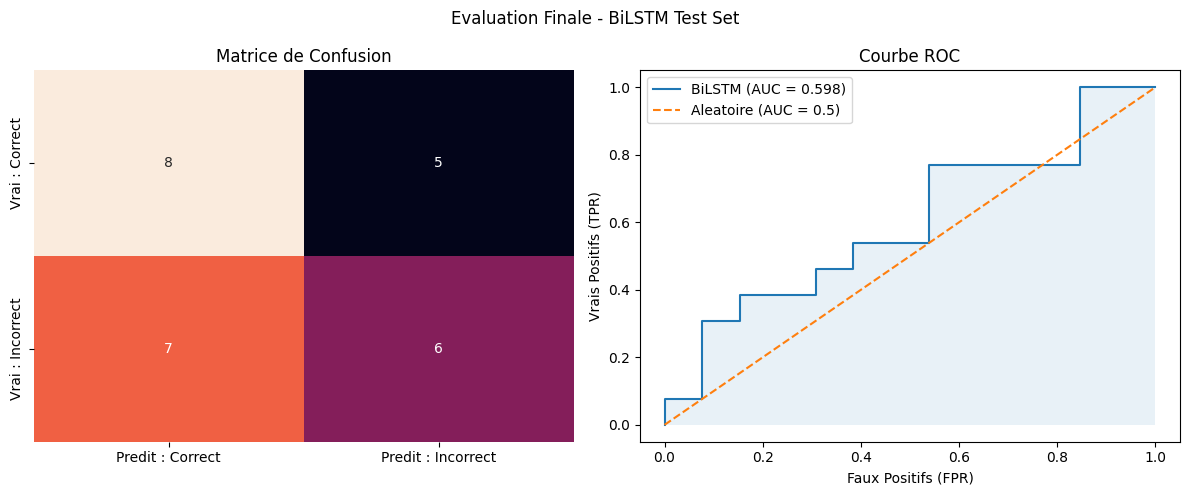

evaluation.png sauvegarde


In [24]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=ax1,
            xticklabels=['Predit : Correct', 'Predit : Incorrect'],
            yticklabels=['Vrai : Correct',   'Vrai : Incorrect'],
            cbar=False)
ax1.set_title('Matrice de Confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_val     = roc_auc_score(all_labels, all_probs)
ax2.plot(fpr, tpr, label=f'BiLSTM (AUC = {auc_val:.3f})')
ax2.plot([0, 1], [0, 1], linestyle='--', label='Aleatoire (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1)
ax2.set_title('Courbe ROC')
ax2.set_xlabel('Faux Positifs (FPR)')
ax2.set_ylabel('Vrais Positifs (TPR)')
ax2.legend()

plt.suptitle('Evaluation Finale - BiLSTM Test Set')
plt.tight_layout()
plt.savefig(f'{BASE}/results/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('evaluation.png sauvegarde')


In [25]:
#  Resume Jour 2
acc_test = np.mean(all_preds == all_labels)
auc_test = roc_auc_score(all_labels, all_probs)

print()
print('=' * 50)
print('JOUR 2 TERMINE')
print('=' * 50)
print(f'  Test Accuracy : {acc_test:.3f}  ({acc_test*100:.1f}%)')
print(f'  AUC-ROC       : {auc_test:.3f}')
print()
print('  Fichiers crees :')
print(f'    model.pt             -> {BASE}/processed/')
print(f'    training_curves.png  -> {BASE}/results/')
print(f'    evaluation.png       -> {BASE}/results/')
print()
print('  Prochain : Jour 3 — Feedback localise par joint')


JOUR 2 TERMINE
  Test Accuracy : 0.538  (53.8%)
  AUC-ROC       : 0.598

  Fichiers crees :
    model.pt             -> /content/fitness_data/processed/
    training_curves.png  -> /content/fitness_data/results/
    evaluation.png       -> /content/fitness_data/results/

  Prochain : Jour 3 — Feedback localise par joint


#Jour 3 — Feedback localise par joint

In [26]:
import shap
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/fitness_data'

ANGLE_NAMES = [
    'genou_gauche', 'genou_droit',
    'hanche_gauche', 'hanche_droite',
    'coude_gauche', 'coude_droit',
    'tronc'
]

# Message feedback par joint
FEEDBACK = {
    'genou_gauche'  : 'Genou gauche en valgus — ramene le genou vers l\'avant',
    'genou_droit'   : 'Genou droit en valgus — ramene le genou vers l\'avant',
    'hanche_gauche' : 'Hanche gauche affaissee — contracte les fessiers',
    'hanche_droite' : 'Hanche droite affaissee — contracte les fessiers',
    'coude_gauche'  : 'Coude gauche mal positionne — serre les coudes',
    'coude_droit'   : 'Coude droit mal positionne — serre les coudes',
    'tronc'         : 'Tronc trop penche — garde le dos droit',
}

print('Imports OK')

Imports OK


In [27]:
#Recharger modele

model.load_state_dict(torch.load(f'{BASE}/processed/model.pt',
                                  map_location=DEVICE))
model.eval()

print(f'Modele charge')
print(f'Test set        : {X_test.shape[0]} sequences')
print(f'Incorrectes     : {(y_test == 1).sum()}')



Modele charge
Test set        : 26 sequences
Incorrectes     : 13


In [34]:
#  Gradient Attribution (remplacement SHAP)


model.eval()

X_incorrect_np = X_test[incorrect_idx]
X_inc = torch.FloatTensor(X_incorrect_np).to(DEVICE)
X_inc.requires_grad_(True)

# Passe forward
out   = model(X_inc)
# Score de la classe 1 (incorrect) pour toutes les sequences
score = out[:, 1].sum()
# Backprop pour calculer le gradient par rapport a chaque angle
score.backward()

# Gradients shape : (N, 60, 7)
grads = X_inc.grad.abs().cpu().detach().numpy()

# Moyenne sur les 60 frames -> (N, 7)
shap_mean = grads.mean(axis=1)

# Normalisation en %
shap_norm = shap_mean / shap_mean.sum(axis=1, keepdims=True)

# Joint dominant par sequence
dominant_joint = shap_norm.argmax(axis=1)

print(f'Gradients shape : {grads.shape}')
print()
print('Contribution moyenne de chaque angle :')
print()
for j, name in enumerate(ANGLE_NAMES):
    contrib = shap_norm[:, j].mean() * 100
    bar     = '#' * int(contrib / 2)
    print(f'  {name:<18} : {contrib:5.1f}%  {bar}')


Gradients shape : (13, 60, 7)

Contribution moyenne de chaque angle :

  genou_gauche       :  11.2%  #####
  genou_droit        :  14.4%  #######
  hanche_gauche      :  18.8%  #########
  hanche_droite      :  13.2%  ######
  coude_gauche       :  11.4%  #####
  coude_droit        :  15.1%  #######
  tronc              :  15.9%  #######


In [35]:
#  Feedback par sequence

with open(f'{BASE}/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print('Exemples de feedback genere automatiquement :')
print('=' * 55)

for i in range(min(8, len(incorrect_idx))):
    seq_idx    = incorrect_idx[i]
    joint_idx  = dominant_joint[i]
    joint_name = ANGLE_NAMES[joint_idx]
    contrib    = shap_norm[i, joint_idx] * 100

    # Angle moyen normalise sur la sequence
    angle_norm  = X_test[seq_idx, :, joint_idx].mean()
    # Inverser le StandardScaler pour retrouver les degres
    angle_reel  = angle_norm * scaler.scale_[joint_idx] + scaler.mean_[joint_idx]

    exercise = meta.iloc[seq_idx]['exercise'] if seq_idx < len(meta) else 'inconnu'

    print(f'Sequence {i+1} | Exercice : {exercise}')
    print(f'  Joint responsable : {joint_name} ({contrib:.1f}% de contribution)')
    print(f'  Angle moyen       : {angle_reel:.1f} deg')
    print(f'  Feedback          : {FEEDBACK[joint_name]}')
    print()




Exemples de feedback genere automatiquement :
Sequence 1 | Exercice : squat
  Joint responsable : hanche_gauche (33.7% de contribution)
  Angle moyen       : 4827.5 deg
  Feedback          : Hanche gauche affaissee — contracte les fessiers

Sequence 2 | Exercice : squat
  Joint responsable : tronc (19.1% de contribution)
  Angle moyen       : 2941.0 deg
  Feedback          : Tronc trop penche — garde le dos droit

Sequence 3 | Exercice : squat
  Joint responsable : hanche_gauche (26.1% de contribution)
  Angle moyen       : 6184.9 deg
  Feedback          : Hanche gauche affaissee — contracte les fessiers

Sequence 4 | Exercice : squat
  Joint responsable : genou_droit (18.2% de contribution)
  Angle moyen       : 6641.0 deg
  Feedback          : Genou droit en valgus — ramene le genou vers l'avant

Sequence 5 | Exercice : squat
  Joint responsable : hanche_gauche (22.7% de contribution)
  Angle moyen       : 6789.9 deg
  Feedback          : Hanche gauche affaissee — contracte les fessi

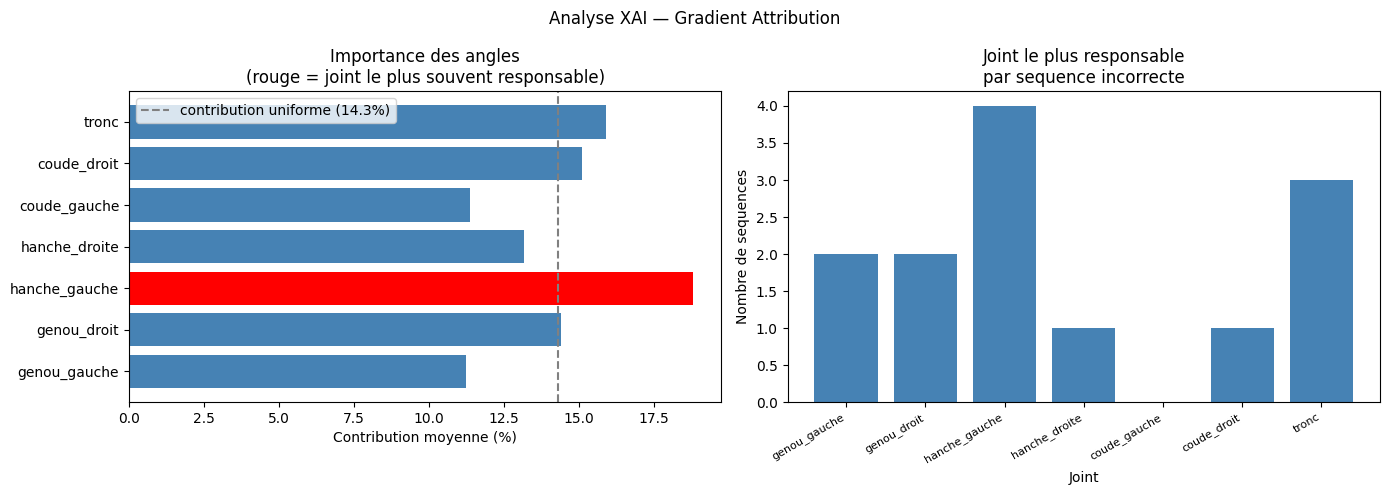

xai_contributions.png sauvegarde


In [41]:
# Heatmap globale des contributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : contribution moyenne
mean_contrib = shap_norm.mean(axis=0) * 100
colors = ['red' if c == mean_contrib.max() else 'steelblue'
          for c in mean_contrib]

axes[0].barh(ANGLE_NAMES, mean_contrib, color=colors)
axes[0].set_xlabel('Contribution moyenne (%)')
axes[0].set_title('Importance des angles\n(rouge = joint le plus souvent responsable)')
axes[0].axvline(x=100/7, color='gray', linestyle='--', label='contribution uniforme (14.3%)')
axes[0].legend()

# Graphique 2 : joint dominant par sequence
joint_counts = np.bincount(dominant_joint, minlength=7)
axes[1].bar(ANGLE_NAMES, joint_counts, color='steelblue')
axes[1].set_xlabel('Joint')
axes[1].set_ylabel('Nombre de sequences')
axes[1].set_title('Joint le plus responsable\npar sequence incorrecte')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Analyse XAI — Gradient Attribution')
plt.tight_layout()
plt.savefig(f'{BASE}/results/xai_contributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('xai_contributions.png sauvegarde')


Exercices presents dans les incorrectes : ['squat']


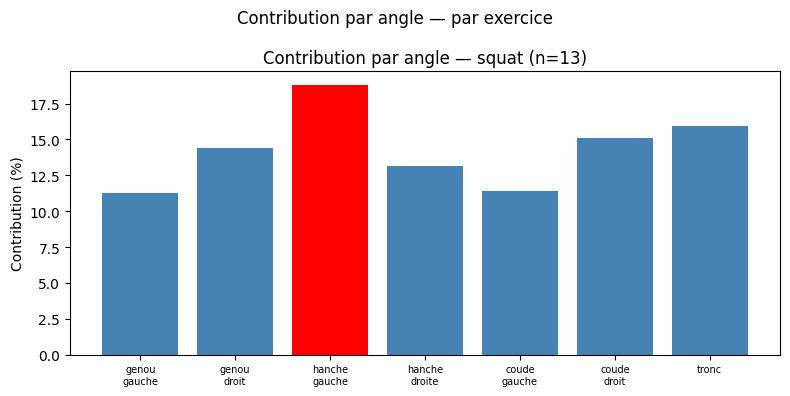

xai_par_exercice.png sauvegarde


In [40]:
# Analyse par exercice
exercises_present = []
for exercise in meta['exercise'].unique():
    ex_mask = np.array([
        meta.iloc[idx]['exercise'] == exercise
        for idx in incorrect_idx
        if idx < len(meta)
    ])
    if ex_mask.sum() > 0:
        exercises_present.append((exercise, ex_mask))

print(f'Exercices presents dans les incorrectes : {[e[0] for e in exercises_present]}')

if len(exercises_present) == 1:
    # Un seul exercice -> pas de comparaison possible
    exercise, ex_mask = exercises_present[0]
    ex_contrib  = shap_norm[ex_mask].mean(axis=0) * 100
    bar_colors  = ['red' if j == ex_contrib.argmax() else 'steelblue' for j in range(7)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(7), ex_contrib, color=bar_colors)
    ax.set_xticks(range(7))
    ax.set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=7)
    ax.set_title(f'Contribution par angle — {exercise} (n={ex_mask.sum()})')
    ax.set_ylabel('Contribution (%)')

else:
    fig, axes = plt.subplots(1, len(exercises_present), figsize=(15, 4))
    for i, (exercise, ex_mask) in enumerate(exercises_present):
        ex_contrib = shap_norm[ex_mask].mean(axis=0) * 100
        bar_colors = ['red' if j == ex_contrib.argmax() else 'steelblue' for j in range(7)]
        axes[i].bar(range(7), ex_contrib, color=bar_colors)
        axes[i].set_xticks(range(7))
        axes[i].set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=7)
        axes[i].set_title(f'{exercise}\n(n={ex_mask.sum()})')
        axes[i].set_ylabel('Contribution (%)')

plt.suptitle('Contribution par angle — par exercice')
plt.tight_layout()
plt.savefig(f'{BASE}/results/xai_par_exercice.png', dpi=150, bbox_inches='tight')
plt.show()
print('xai_par_exercice.png sauvegarde')

In [42]:
#  Resume Jour 3
print('=' * 50)
print('JOUR 3 TERMINE')
print('=' * 50)
print()
print('Ce qu\'on a fait :')
print('  1. Calcule les SHAP values sur les sequences incorrectes')
print('  2. Identifie le joint responsable par sequence')
print('  3. Genere un feedback texte actionnable par joint')
print('  4. Visualise les contributions par angle et par exercice')
print()
print('Fichiers crees :')
print(f'  xai_contributions.png  -> {BASE}/results/')
print(f'  xai_par_exercice.png   -> {BASE}/results/')
print()
print('Prochain : Jour 4 — Dashboard complet')

JOUR 3 TERMINE

Ce qu'on a fait :
  1. Calcule les SHAP values sur les sequences incorrectes
  2. Identifie le joint responsable par sequence
  3. Genere un feedback texte actionnable par joint
  4. Visualise les contributions par angle et par exercice

Fichiers crees :
  xai_contributions.png  -> /content/fitness_data/results/
  xai_par_exercice.png   -> /content/fitness_data/results/

Prochain : Jour 4 — Dashboard complet


# Jour 4 — Dashboard complet

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import pickle
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/fitness_data'

ANGLE_NAMES = [
    'genou_gauche', 'genou_droit',
    'hanche_gauche', 'hanche_droite',
    'coude_gauche', 'coude_droit',
    'tronc'
]

print('Imports OK')
print('Toutes les variables doivent etre en memoire depuis Jours 1-3 :')
print(f'  X           : {X.shape}')
print(f'  y           : {y.shape}')
print(f'  history     : {list(history.keys())}')
print(f'  all_preds   : {len(all_preds)} predictions')
print(f'  shap_norm   : {shap_norm.shape}')



Imports OK
Toutes les variables doivent etre en memoire depuis Jours 1-3 :
  X           : (254, 60, 7)
  y           : (254,)
  history     : ['train_loss', 'val_loss', 'train_acc', 'val_acc']
  all_preds   : 26 predictions
  shap_norm   : (13, 7)


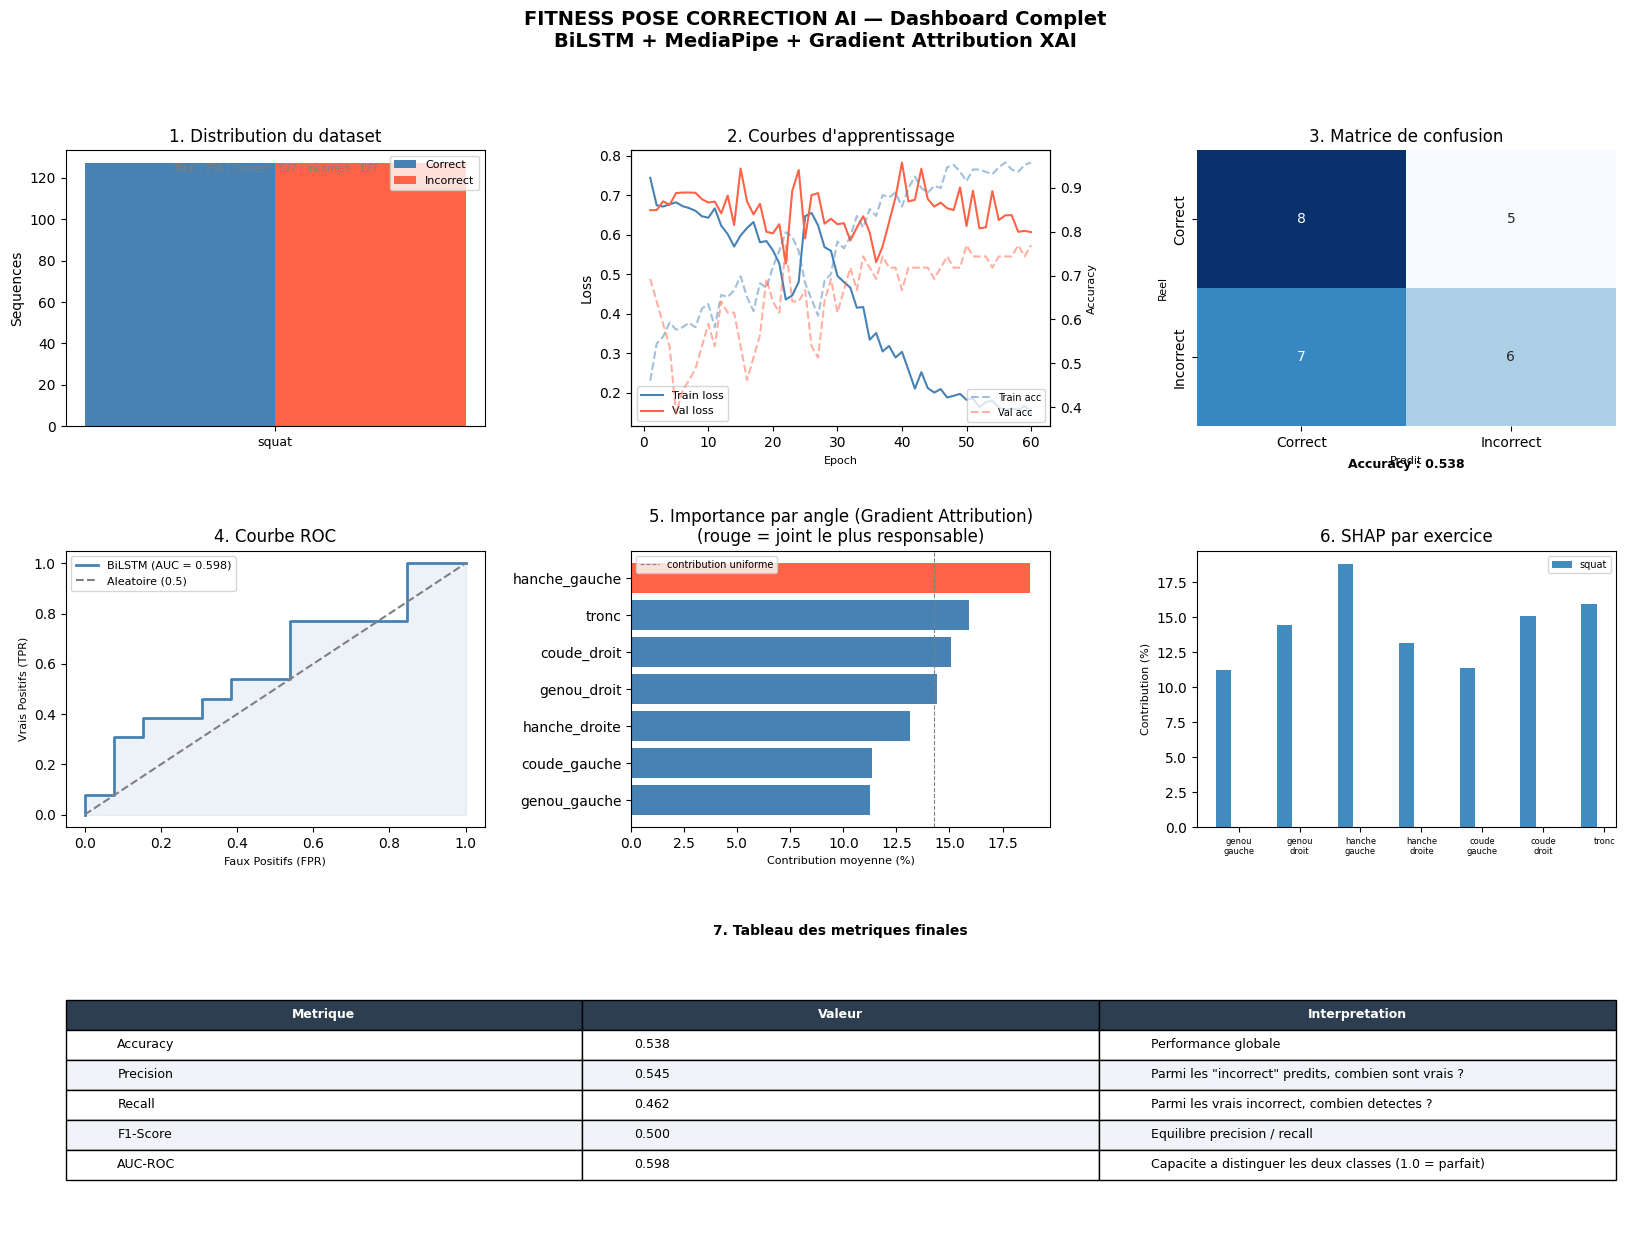

dashboard.png sauvegarde


In [44]:

# CELLULE 2 : Dashboard complet

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

#Graphique 1 : Distribution du dataset
ax1 = fig.add_subplot(gs[0, 0])

meta_counts = meta.groupby(['exercise', 'label_str']).size().unstack()
exercises   = meta_counts.index.tolist()
x_pos       = np.arange(len(exercises))
width       = 0.35

ax1.bar(x_pos - width/2, meta_counts['correct'],   width, label='Correct',   color='steelblue')
ax1.bar(x_pos + width/2, meta_counts['incorrect'], width, label='Incorrect', color='tomato')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(exercises, fontsize=9)
ax1.set_ylabel('Sequences')
ax1.set_title('1. Distribution du dataset')
ax1.legend(fontsize=8)

total    = len(y)
n_corr   = (y == 0).sum()
n_incorr = (y == 1).sum()
ax1.text(0.5, 0.95, f'Total : {total} | Correct : {n_corr} | Incorrect : {n_incorr}',
         transform=ax1.transAxes, ha='center', va='top', fontsize=7, color='gray')


# Graphique 2 : Courbes d'apprentissage
ax2 = fig.add_subplot(gs[0, 1])

ep = range(1, len(history['train_loss']) + 1)
ax2.plot(ep, history['train_loss'], label='Train loss', color='steelblue')
ax2.plot(ep, history['val_loss'],   label='Val loss',   color='tomato')
ax2.set_xlabel('Epoch', fontsize=8)
ax2.set_ylabel('Loss')
ax2.set_title('2. Courbes d\'apprentissage')
ax2.legend(fontsize=8)

ax2b = ax2.twinx()
ax2b.plot(ep, history['train_acc'], linestyle='--', color='steelblue', alpha=0.5, label='Train acc')
ax2b.plot(ep, history['val_acc'],   linestyle='--', color='tomato',    alpha=0.5, label='Val acc')
ax2b.set_ylabel('Accuracy', fontsize=8)
ax2b.legend(fontsize=7, loc='lower right')


#Graphique 3 : Matrice de confusion
ax3 = fig.add_subplot(gs[0, 2])

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=ax3,
            xticklabels=['Correct', 'Incorrect'],
            yticklabels=['Correct', 'Incorrect'],
            cbar=False, cmap='Blues')
ax3.set_xlabel('Predit', fontsize=8)
ax3.set_ylabel('Reel', fontsize=8)
ax3.set_title('3. Matrice de confusion')

acc = np.mean(np.array(all_preds) == np.array(all_labels))
ax3.text(0.5, -0.15, f'Accuracy : {acc:.3f}',
         transform=ax3.transAxes, ha='center', fontsize=9, fontweight='bold')


# Graphique 4 : Courbe ROC
ax4 = fig.add_subplot(gs[1, 0])

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_val     = roc_auc_score(all_labels, all_probs)
ax4.plot(fpr, tpr, color='steelblue', lw=2, label=f'BiLSTM (AUC = {auc_val:.3f})')
ax4.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire (0.5)')
ax4.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax4.set_xlabel('Faux Positifs (FPR)', fontsize=8)
ax4.set_ylabel('Vrais Positifs (TPR)', fontsize=8)
ax4.set_title('4. Courbe ROC')
ax4.legend(fontsize=8)


#Graphique 5 : SHAP contributions globales
ax5 = fig.add_subplot(gs[1, 1])

mean_contrib = shap_norm.mean(axis=0) * 100
sorted_idx   = np.argsort(mean_contrib)
colors       = ['tomato' if i == sorted_idx[-1] else 'steelblue'
                for i in range(7)]
colors_sorted = [colors[i] for i in sorted_idx]

ax5.barh([ANGLE_NAMES[i] for i in sorted_idx], mean_contrib[sorted_idx],
         color=colors_sorted)
ax5.axvline(x=100/7, color='gray', linestyle='--', linewidth=0.8,
            label='contribution uniforme')
ax5.set_xlabel('Contribution moyenne (%)', fontsize=8)
ax5.set_title('5. Importance par angle (Gradient Attribution)\n(rouge = joint le plus responsable)')
ax5.legend(fontsize=7)


#  Graphique 6 : SHAP par exercice
ax6 = fig.add_subplot(gs[1, 2])

exercises_list = meta['exercise'].unique()
incorrect_idx  = np.where(y_test == 1)[0]

data_ex = []
for exercise in exercises_list:
    ex_mask = np.array([
        meta.iloc[idx]['exercise'] == exercise
        for idx in incorrect_idx
        if idx < len(meta)
    ])
    if ex_mask.sum() > 0:
        ex_contrib = shap_norm[ex_mask].mean(axis=0) * 100
        data_ex.append(ex_contrib)

data_ex = np.array(data_ex)
x_ex    = np.arange(7)
width   = 0.25

for i, exercise in enumerate(exercises_list):
    if i < len(data_ex):
        ax6.bar(x_ex + i * width, data_ex[i], width, label=exercise, alpha=0.85)

ax6.set_xticks(x_ex + width)
ax6.set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=6)
ax6.set_ylabel('Contribution (%)', fontsize=8)
ax6.set_title('6. SHAP par exercice')
ax6.legend(fontsize=7)


#Graphique 7 : Metriques resume
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)

metriques = [
    ('Accuracy',  f'{acc:.3f}',     'Performance globale'),
    ('Precision', f'{precision:.3f}', 'Parmi les "incorrect" predits, combien sont vrais ?'),
    ('Recall',    f'{recall:.3f}',    'Parmi les vrais incorrect, combien detectes ?'),
    ('F1-Score',  f'{f1:.3f}',        'Equilibre precision / recall'),
    ('AUC-ROC',   f'{auc_val:.3f}',   'Capacite a distinguer les deux classes (1.0 = parfait)'),
]

col_labels = ['Metrique', 'Valeur', 'Interpretation']
table_data = [[m[0], m[1], m[2]] for m in metriques]

table = ax7.table(
    cellText    = table_data,
    colLabels   = col_labels,
    loc         = 'center',
    cellLoc     = 'left',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(metriques) + 1):
    bg = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(3):
        table[i, j].set_facecolor(bg)

ax7.set_title('7. Tableau des metriques finales', fontsize=10, fontweight='bold', pad=12)


#  Titre general
fig.suptitle(
    'FITNESS POSE CORRECTION AI — Dashboard Complet\n'
      'BiLSTM + MediaPipe + Gradient Attribution XAI',
    fontsize=14, fontweight='bold', y=0.98
)

plt.savefig(f'{BASE}/results/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('dashboard.png sauvegarde')




In [46]:

# CELLULE 3 : Resume Jour 4
print('=' * 50)
print('JOUR 4 TERMINE')
print('=' * 50)
print()
print('Done :')
print('  1. Assemble tous les resultats Jours 1-2-3')
print('  2. Cree un dashboard de 7 graphiques en une page')
print('  3. Ajoute un tableau de metriques synthetique')
print()
print('Fichier cree :')
print(f'  dashboard.png  -> {BASE}/results/')
print()
print('Prochain : Jour 5 — Comparaison de modeles')
print('  (LSTM vs GRU vs MLP vs Random Forest)')

JOUR 4 TERMINE

Done :
  1. Assemble tous les resultats Jours 1-2-3
  2. Cree un dashboard de 7 graphiques en une page
  3. Ajoute un tableau de metriques synthetique

Fichier cree :
  dashboard.png  -> /content/fitness_data/results/

Prochain : Jour 5 — Comparaison de modeles
  (LSTM vs GRU vs MLP vs Random Forest)


#Jour 5 — Comparaison de modeles